# Optimal CCN diameter from the susceptibility plateau, validated against the weighted activation diameter

**Scientific question.** At each global grid cell, the CCN–CDNC susceptibility
$\beta(D)$ rises with the CCN cutoff diameter $D$ and then plateaus: beyond a
certain size, adding larger particles no longer increases the susceptibility.
The diameter at which that plateau begins — the **plateau edge** — is a natural
"optimal" CCN diameter for predicting CDNC. Does this purely susceptibility-derived
diameter agree with the physically-derived **weighted activation diameter**
(`Dact_weighted`, the NCONC-weighted bulk activation size computed from the
lognormal mode parameters)?

**Approach.**

1. For every grid cell, detect the plateau edge of the all-levels susceptibility
   profile $\beta(D)$ using a smoothed-gradient method (`find_plateau_edge`).
2. Map that optimal diameter globally and summarise its distribution.
3. Validate against `Dact_weighted`: for each cell, ask where the plateau edge
   falls within that cell's activation-diameter distribution (percentile rank),
   and whether the edge tracks the cell's **median** or **mean** activation
   diameter (paired Wilcoxon, log–log correlation).

A percentile rank near 50% and a closer match to the median than the mean would
indicate the susceptibility plateau edge is effectively picking out the typical
activation size of the aerosol population.

## 1 · Setup and data

`susceptibility_all_levels.nc` holds the all-levels susceptibility slope on a
`(lat, lon, radius, updraft_q)` grid; we take the `'Total'` updraft selection.
`Dact_weighted.nc` holds the weighted activation diameter on `(time, lev, lat,
lon)`.

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
SUSC_DIR = Path("/share/pech2273/susceptibility")
ACT_DIR  = Path("/share/pech2273")

GRAD_SIGMA     = 1.5    # gaussian smoothing width for the gradient
DROP_THRESHOLD = 0.05   # normalised gradient below -this marks the plateau edge
DACT_FLOOR     = 1.0    # drop sub-nm activation-diameter tail [nm]

ds_alllevels = xr.open_dataset(SUSC_DIR / "susceptibility_all_levels.nc")
ds_actD      = xr.open_dataset(ACT_DIR / "Dact_weighted.nc")
ds_actD

<xarray.Dataset> Size: 6GB
Dimensions:        (lat: 96, lon: 144, lev: 10, time: 11689)
Coordinates:
  * lat            (lat) float64 768B -90.0 -88.11 -86.21 ... 86.21 88.11 90.0
  * lon            (lon) float64 1kB 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lev            (lev) float64 80B 691.4 763.4 820.9 ... 957.5 976.3 992.6
  * time           (time) datetime64[ns] 94kB 2011-01-01 ... 2015-01-01
Data variables:
    Dact_weighted  (time, lev, lat, lon) float32 6GB ...

## 2 · Plateau-edge optimal diameter per grid cell

`find_plateau_edge` smooths the susceptibility-vs-diameter profile, takes its
gradient, normalises by the profile range, and returns the diameter just before
the gradient first drops below `-DROP_THRESHOLD` — i.e. where the rise flattens.
A flat profile returns NaN; a profile that never declines returns the largest
diameter.

In [2]:
def find_plateau_edge(profile, diameter, sigma=GRAD_SIGMA,
                      drop_threshold=DROP_THRESHOLD):
    """Diameter at which a susceptibility profile stops rising (plateau edge).

    Parameters
    ----------
    profile : array-like
        Susceptibility as a function of diameter, one grid cell.
    diameter : array-like
        Diameter axis [nm], same length as ``profile``.
    sigma : float
        Gaussian smoothing width (in samples) applied before differentiating.
    drop_threshold : float
        The plateau edge is the last sample before the range-normalised
        gradient first falls below ``-drop_threshold``.

    Returns
    -------
    float
        Plateau-edge diameter [nm], or NaN for a flat profile.
    """
    smooth = gaussian_filter1d(profile, sigma=sigma)
    gradient = np.gradient(smooth)
    profile_range = smooth.max() - smooth.min()
    if profile_range == 0:
        return np.nan
    norm_gradient = gradient / profile_range
    decline = np.where(norm_gradient < -drop_threshold)[0]
    if len(decline) == 0:
        return diameter[-1]          # never declines -> largest diameter
    edge_idx = max(0, decline[0] - 1)
    return diameter[edge_idx]

In [3]:
# All-levels susceptibility, Total updraft selection -> (lat, lon, radius)
data = ds_alllevels.slope.sel(updraft_q="Total")
lat = data.lat.values
lon = data.lon.values
radius = data.radius.values
diameter = radius * 2.0                       # nm

# Flatten to (n_gridpoints, n_radius); drop cells with any NaN across radius
vals = data.values.reshape(-1, len(radius))   # (96*144, n_radius)
valid_mask = ~np.any(np.isnan(vals), axis=1)
vals_valid = vals[valid_mask]

# Plateau edge per valid cell, then scatter back onto the full grid
optimal_valid = np.array([
    find_plateau_edge(vals_valid[k], diameter) for k in range(len(vals_valid))
])
optimal_full = np.full(valid_mask.shape, np.nan)
optimal_full[valid_mask] = optimal_valid
optimal_diameters_2d = optimal_full.reshape(len(lat), len(lon))

print(f"Optimal (plateau-edge) diameter — valid cells: {valid_mask.sum()}")
print(f"  min={np.nanmin(optimal_diameters_2d):.1f}  "
      f"max={np.nanmax(optimal_diameters_2d):.1f}  "
      f"mean={np.nanmean(optimal_diameters_2d):.1f}  "
      f"median={np.nanmedian(optimal_diameters_2d):.1f} nm")

Optimal (plateau-edge) diameter — valid cells: 13264
  min=5.1  max=1002.4  mean=115.6  median=113.8 nm


### Figure 1 — Global map of the optimal CCN diameter

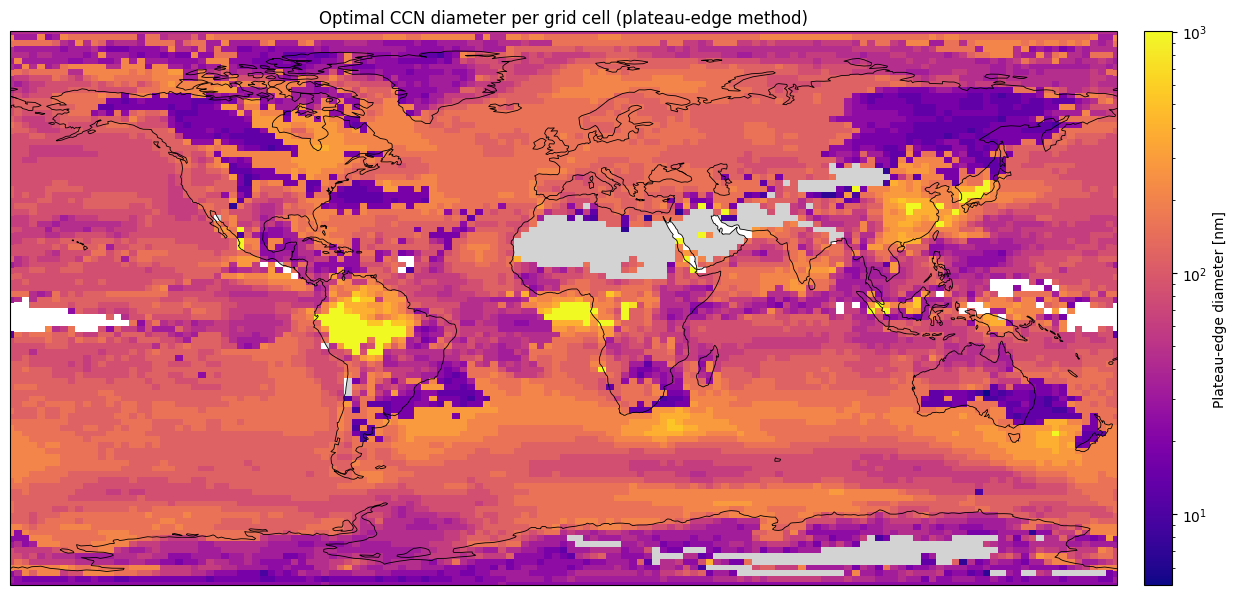

In [4]:
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
cmap = plt.cm.plasma.copy()
cmap.set_bad(alpha=0)
im = ax.pcolormesh(
    lon, lat, np.ma.masked_invalid(optimal_diameters_2d), cmap=cmap,
    norm=mpl.colors.LogNorm(vmin=np.nanmin(optimal_diameters_2d),
                            vmax=np.nanmax(optimal_diameters_2d)),
    transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
cb = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02)
cb.set_label("Plateau-edge diameter [nm]")
ax.set_title("Optimal CCN diameter per grid cell (plateau-edge method)")
fig.tight_layout()
plt.show()

### Figure 2 — Distribution of optimal diameters

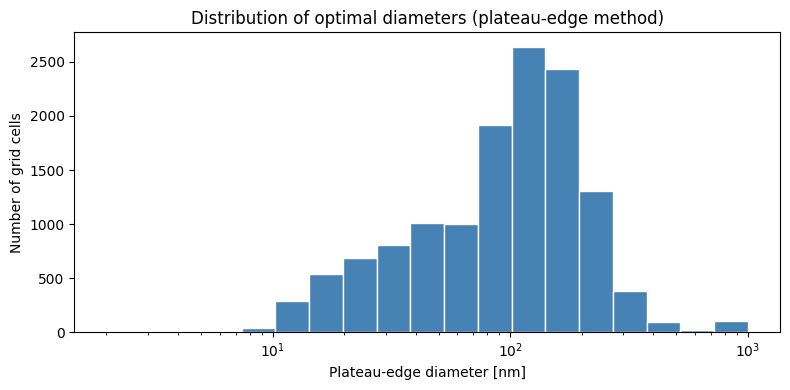

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
log_bins = np.logspace(np.log10(diameter.min()), np.log10(diameter.max()), 20)
ax.hist(optimal_valid, bins=log_bins, color="steelblue", edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Plateau-edge diameter [nm]")
ax.set_ylabel("Number of grid cells")
ax.set_title("Distribution of optimal diameters (plateau-edge method)")
fig.tight_layout()
plt.show()

## 3 · Validation against the weighted activation diameter

Load `Dact_weighted` and pool over time and level (matching the all-levels
plateau edge). We keep three views of each cell's activation-diameter
distribution: the full pooled sample (for percentile rank), and the per-cell
mean and median (for the paired comparison). The sub-nm tail is dropped with
`DACT_FLOOR`.

In [6]:
dact = ds_actD["Dact_weighted"].where(ds_actD["Dact_weighted"] >= DACT_FLOOR)

# Pool over whatever sampling dims are present (time and/or lev)
sample_dims = [d for d in ("time", "lev") if d in dact.dims]

dact_mean   = dact.mean(dim=sample_dims, skipna=True).transpose("lat", "lon").values
dact_median = dact.median(dim=sample_dims, skipna=True).transpose("lat", "lon").values

# Collapse sampling dims into ONE axis -> (sample, lat, lon)
dact_stack = dact.stack(sample=sample_dims).transpose("sample", "lat", "lon")
dvals = dact_stack.values

edge = optimal_diameters_2d                  # (lat, lon)

# Grid-alignment guards: same shape and same coordinates as the edge map
assert dvals.shape[1:] == edge.shape, (dvals.shape, edge.shape)
np.testing.assert_allclose(dact_stack.lat.values, lat)
np.testing.assert_allclose(dact_stack.lon.values, lon)

### Per-cell percentile rank of the plateau edge

For each cell, what fraction of that cell's activation-diameter samples fall at
or below the plateau edge? A rank near 50% means the edge sits at the cell's
median activation diameter.

In [7]:
nlat, nlon = edge.shape
pct_rank = np.full((nlat, nlon), np.nan)
for i in range(nlat):
    for j in range(nlon):
        e = edge[i, j]
        col = dvals[:, i, j]
        col = col[np.isfinite(col)]
        if np.isfinite(e) and col.size > 5:
            pct_rank[i, j] = 100.0 * np.mean(col <= e)

pr = pct_rank[np.isfinite(pct_rank)]
print("Percentile rank of plateau edge within each cell's Dact distribution:")
print(f"  n cells     = {pr.size}")
print(f"  median rank = {np.median(pr):.1f}%    mean rank = {pr.mean():.1f}%")
print(f"  fraction with edge in 25-75th pct of Dact: "
      f"{np.mean((pr >= 25) & (pr <= 75)):.1%}")

Percentile rank of plateau edge within each cell's Dact distribution:
  n cells     = 13264
  median rank = 53.0%    mean rank = 50.6%
  fraction with edge in 25-75th pct of Dact: 26.5%


### Paired comparison: edge vs per-cell mean and median

Across all cells with finite edge, mean, and median, compare the plateau edge to
each reference with a paired Wilcoxon test and a log–log correlation, and count
how often the edge is closer to the cell's median than its mean.

In [8]:
m = np.isfinite(edge) & np.isfinite(dact_mean) & np.isfinite(dact_median)
e, dmu, dmd = edge[m], dact_mean[m], dact_median[m]

print(f"Paired comparison across {e.size} cells:")
for name, ref in [("per-cell MEAN", dmu), ("per-cell MEDIAN", dmd)]:
    d = e - ref
    w = stats.wilcoxon(d)
    r = np.corrcoef(np.log(e), np.log(ref))[0, 1]
    print(f"\nEdge vs {name}:")
    print(f"  median(edge - ref) = {np.median(d):+.2f} nm")
    print(f"  mean  (edge - ref) = {d.mean():+.2f} nm")
    print(f"  Wilcoxon: W={w.statistic:.0f}, p={w.pvalue:.3g}")
    print(f"  log-log Pearson r = {r:.3f}")

closer_to_median = np.abs(e - dmd) < np.abs(e - dmu)
print(f"\nEdge is closer to the cell's MEDIAN than its MEAN in "
      f"{np.mean(closer_to_median):.1%} of cells.")

Paired comparison across 13264 cells:

Edge vs per-cell MEAN:
  median(edge - ref) = +0.40 nm
  mean  (edge - ref) = +16.36 nm
  Wilcoxon: W=39155760, p=6.33e-28
  log-log Pearson r = 0.300

Edge vs per-cell MEDIAN:
  median(edge - ref) = +2.22 nm
  mean  (edge - ref) = +18.50 nm
  Wilcoxon: W=37762903, p=3.17e-45
  log-log Pearson r = 0.309

Edge is closer to the cell's MEDIAN than its MEAN in 57.0% of cells.


### Figure 3 — Map of percentile rank

Blue/red around 50% (white) indicates the plateau edge tracks the cell's median
activation diameter; saturated colours mark cells where the edge sits in the
tails of the activation-diameter distribution.

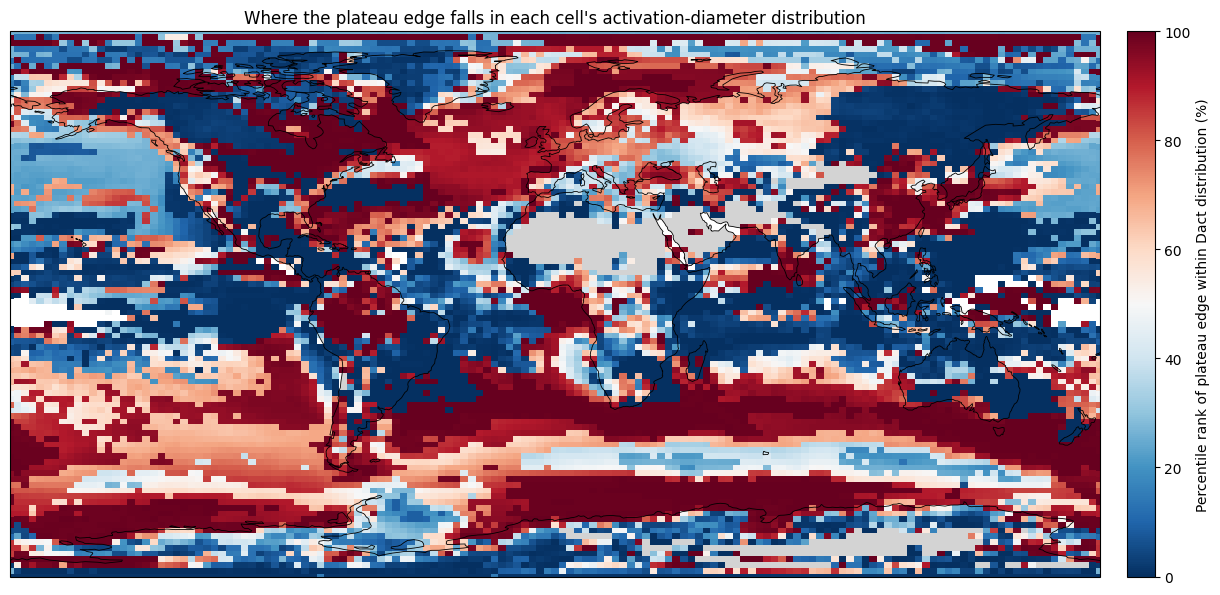

In [9]:
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
im = ax.pcolormesh(lon, lat, np.ma.masked_invalid(pct_rank),
                   cmap="RdBu_r", vmin=0, vmax=100,
                   transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label("Percentile rank of plateau edge within Dact distribution (%)")
ax.set_title("Where the plateau edge falls in each cell's "
             "activation-diameter distribution")
fig.tight_layout()
plt.show()

### Figure 4 — Median activation diameter map (reference)

The per-cell median `Dact` for context alongside the rank map above.
This section looks at the distribution of the activation diameters vertically and some comparisons to the plateau edge detection. 

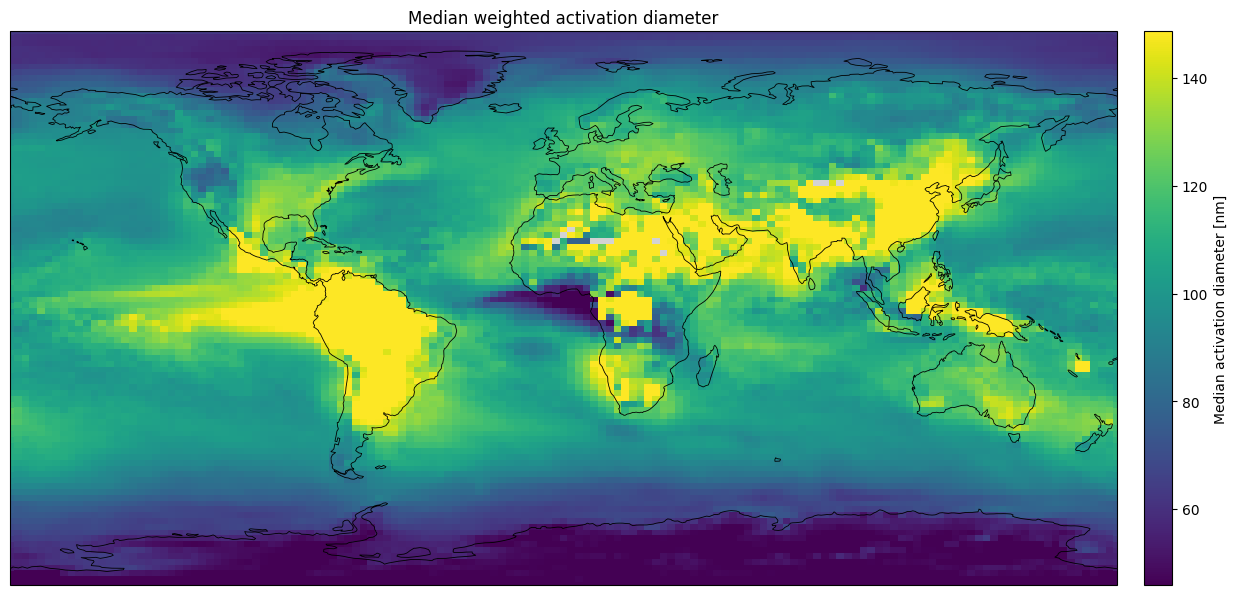

In [10]:
fig, ax = plt.subplots(figsize=(14, 6),
                       subplot_kw={"projection": ccrs.PlateCarree()})
im = ax.pcolormesh(
    lon, lat, np.ma.masked_invalid(dact_median), cmap="viridis",
    vmin=np.nanquantile(dact_median, 0.05),
    vmax=np.nanquantile(dact_median, 0.95),
    transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
cb = plt.colorbar(im, ax=ax, pad=0.02)
cb.set_label("Median activation diameter [nm]")
ax.set_title("Median weighted activation diameter")
fig.tight_layout()
plt.show()

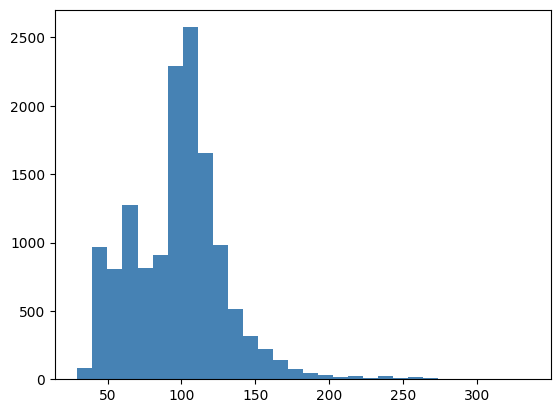

In [21]:
plt.hist(dact_median.flatten(), bins=30,
         color="steelblue")
plt.show()

### Figure 5 — Optimal diameter vs median activation diameter

Direct overlay of the two diameter distributions on shared log bins: the
plateau-edge optimal diameter and the per-cell median activation diameter.

In [11]:
dact_median.flatten()

array([40.736855, 40.685436, 40.72838 , ..., 62.785408, 62.97554 ,
       62.9061  ], shape=(13824,), dtype=float32)

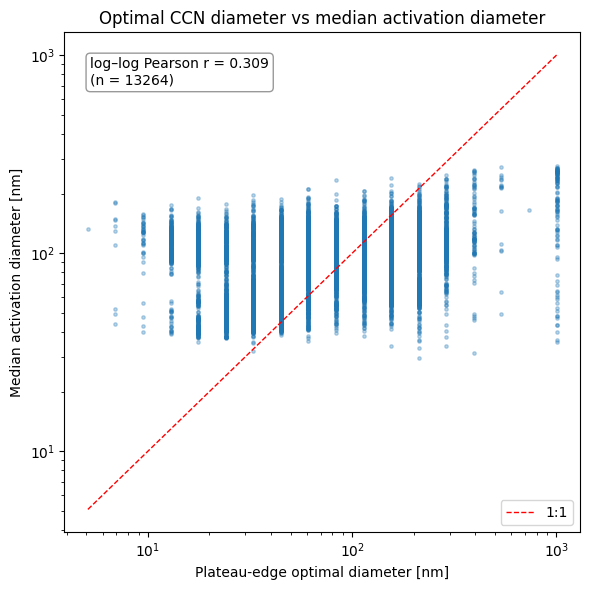

In [12]:
edge_flat = optimal_diameters_2d.flatten()   # full grid, NaN where invalid
dmd_flat  = dact_median.flatten()            # full grid

m = np.isfinite(edge_flat) & np.isfinite(dmd_flat)
x, y = edge_flat[m], dmd_flat[m]

# Pearson r in log space (matches the log axes and the wide diameter range)
r_log, p_log = stats.pearsonr(np.log(x), np.log(y))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s=6, alpha=0.3)
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
ax.plot(lims, lims, "--", color="red", lw=1, label="1:1")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Plateau-edge optimal diameter [nm]")
ax.set_ylabel("Median activation diameter [nm]")
ax.set_title("Optimal CCN diameter vs median activation diameter")
ax.text(0.05, 0.95, f"log–log Pearson r = {r_log:.3f}\n(n = {x.size})",
        transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

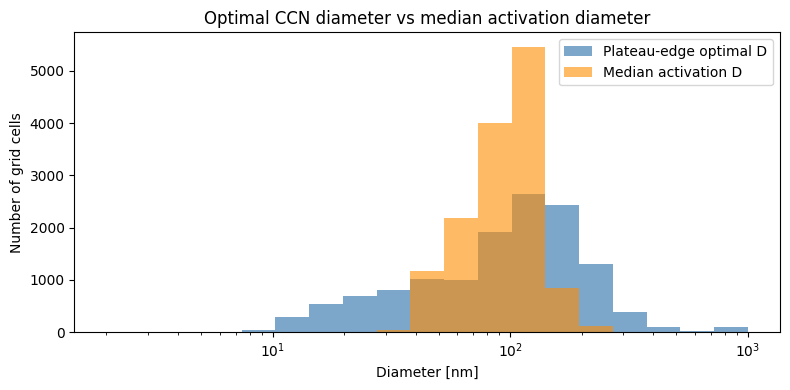

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
log_bins = np.logspace(np.log10(diameter.min()), np.log10(diameter.max()), 20)
ax.hist(optimal_valid, bins=log_bins, color="steelblue", alpha=0.7,
        label="Plateau-edge optimal D")
ax.hist(dact_median[np.isfinite(dact_median)], bins=log_bins,
        color="darkorange", alpha=0.6, label="Median activation D")
ax.set_xscale("log")
ax.set_xlabel("Diameter [nm]")
ax.set_ylabel("Number of grid cells")
ax.set_title("Optimal CCN diameter vs median activation diameter")
ax.legend()
fig.tight_layout()
plt.show()

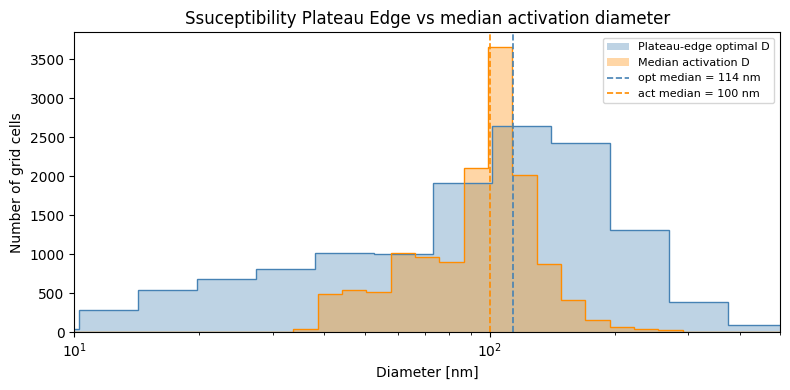

In [56]:
fig, ax = plt.subplots(figsize=(8, 4))

opt = optimal_valid[np.isfinite(optimal_valid)]
med = dact_median[np.isfinite(dact_median)]

# Optimal-D: original binning, unchanged
opt_bins = np.logspace(np.log10(diameter.min()), np.log10(diameter.max()), 20)

# Median activation-D: finer bins over 10–500 nm
lo, hi = 10, 500
med_bins = np.logspace(np.log10(lo), np.log10(hi), 30)
med_r = med[(med >= lo) & (med <= hi)]   # trim to the window for honest edge bins

ax.hist(opt, bins=opt_bins, histtype='stepfilled', alpha=0.35,
        color='steelblue', label='Plateau-edge optimal D')
ax.hist(med_r, bins=med_bins, histtype='stepfilled', alpha=0.35,
        color='darkorange', label='Median activation D')
ax.hist(opt, bins=opt_bins, histtype='step', lw=1.6, color='steelblue')
ax.hist(med_r, bins=med_bins, histtype='step', lw=1.6, color='darkorange')

ax.axvline(np.median(opt), color='steelblue', ls='--', lw=1.2,
           label=f'opt median = {np.median(opt):.0f} nm')
ax.axvline(np.median(med_r), color='darkorange', ls='--', lw=1.2,
           label=f'act median = {np.median(med_r):.0f} nm')

ax.set_xscale('log')
ax.set_xlim(lo, hi)
ax.set_xlabel('Diameter [nm]')
ax.set_ylabel('Number of grid cells')
ax.set_title('Ssuceptibility Plateau Edge vs median activation diameter')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

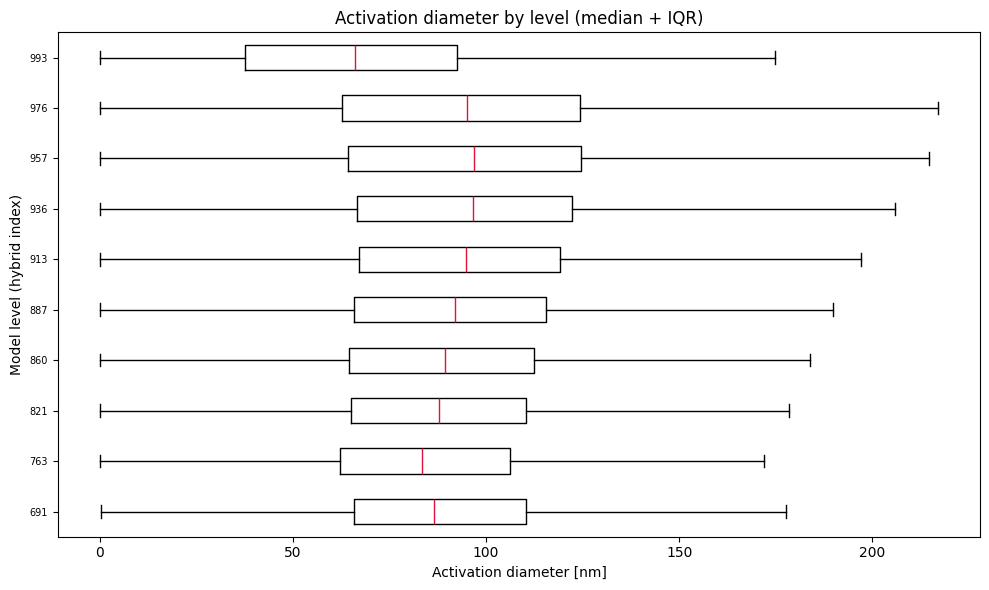

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

data_by_lev = [da.sel(lev=lv).values.ravel()[
                   np.isfinite(da.sel(lev=lv).values.ravel())]
               for lv in levs]

ax.boxplot(data_by_lev, vert=False, showfliers=False,
           medianprops=dict(color='crimson'))
ax.set_yticks(range(1, len(levs) + 1))
ax.set_yticklabels([f'{lv:.0f}' for lv in levs], fontsize=7)
ax.set_xlabel('Activation diameter [nm]')
ax.set_ylabel('Model level (hybrid index)')
ax.set_title('Activation diameter by level (median + IQR)')
plt.tight_layout()
plt.show()

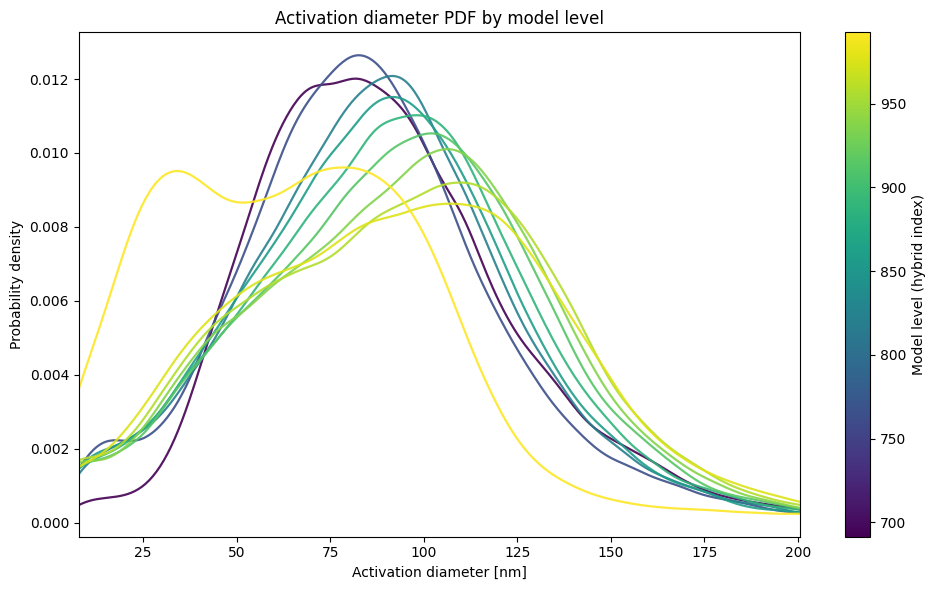

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.stats import gaussian_kde

# --- Grab the activation-diameter variable ---
da = ds_actD['Dact_weighted'] if hasattr(ds_actD, 'data_vars') else ds_actD

levs = da['lev'].values
norm = Normalize(vmin=levs.min(), vmax=levs.max())
cmap = cm.viridis

# Evaluation grid (1–99% of pooled data, so tails don't stretch the axis)
allvals = da.values.ravel()
allvals = allvals[np.isfinite(allvals)]
x = np.linspace(np.nanquantile(allvals, 0.01),
                np.nanquantile(allvals, 0.99), 400)

fig, ax = plt.subplots(figsize=(10, 6))

for lv in levs:
    vals = da.sel(lev=lv).values.ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size < 2:
        continue
    # subsample for speed if the level has a huge number of points
    if vals.size > 50_000:
        vals = np.random.default_rng(0).choice(vals, 50_000, replace=False)
    kde = gaussian_kde(vals)
    ax.plot(x, kde(x), color=cmap(norm(lv)), linewidth=1.6, alpha=0.9)

ax.set_xlabel('Activation diameter [nm]')
ax.set_ylabel('Probability density')
ax.set_title('Activation diameter PDF by model level')
ax.margins(x=0)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Model level (hybrid index)')

plt.tight_layout()
plt.show()

In [43]:
da = ds_actD['Dact_weighted']

vals = da.values.ravel()

n_total   = vals.size
n_nan     = np.isnan(vals).sum()
n_finite  = np.isfinite(vals).sum()
n_exact0  = (vals == 0).sum()                       # exactly zero
n_tiny    = np.isfinite(vals) & (vals < 1e-6)       # ~0 within float noise
n_tiny    = n_tiny.sum()

print(f"total cells      : {n_total:,}")
print(f"NaN              : {n_nan:,}  ({100*n_nan/n_total:.2f}%)")
print(f"finite           : {n_finite:,}")
print(f"exactly 0        : {n_exact0:,}  ({100*n_exact0/n_total:.4f}%)")
print(f"< 1e-6 (near 0)  : {n_tiny:,}  ({100*n_tiny/n_total:.4f}%)")

total cells      : 1,615,887,360
NaN              : 1,495,106,073  (92.53%)
finite           : 120,781,287
exactly 0        : 0  (0.0000%)
< 1e-6 (near 0)  : 2  (0.0000%)


In [45]:
for lv in da['lev'].values:
    v = da.sel(lev=lv).values.ravel()
    z = (v < 10).sum()
    print(f"lev {lv:>6.1f}: {z:,} less than 10 nm")

lev  691.4: 13,281 less than 10 nm
lev  763.4: 75,009 less than 10 nm
lev  820.9: 137,549 less than 10 nm
lev  859.5: 183,016 less than 10 nm
lev  887.0: 197,764 less than 10 nm
lev  912.6: 204,511 less than 10 nm
lev  936.2: 223,082 less than 10 nm
lev  957.5: 227,691 less than 10 nm
lev  976.3: 167,912 less than 10 nm
lev  992.6: 264,570 less than 10 nm


In [46]:
import numpy as np
import pandas as pd

da = ds_actD['Dact_weighted']

# --- Thresholds to probe ---
thresholds = [5, 10, 20]        # nm; 20 nm ≈ your smallest-mode / N20 boundary
lo_floor   = 5                  # "physically implausible" floor

rows = []
for lv in da['lev'].values:
    v = da.sel(lev=lv).values.ravel()
    v = v[np.isfinite(v)]           # this level's valid cells only
    n = v.size
    row = {'lev': lv, 'n_valid': n}
    for t in thresholds:
        c = int((v < t).sum())
        row[f'<{t}nm'] = c
        row[f'<{t}nm_%'] = 100 * c / n if n else np.nan
    rows.append(row)

df = pd.DataFrame(rows)

# --- Column-total row ---
allv = da.values.ravel()
allv = allv[np.isfinite(allv)]
tot = {'lev': 'ALL', 'n_valid': allv.size}
for t in thresholds:
    c = int((allv < t).sum())
    tot[f'<{t}nm'] = c
    tot[f'<{t}nm_%'] = 100 * c / allv.size
df = pd.concat([df, pd.DataFrame([tot])], ignore_index=True)

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(df.to_string(index=False))

    lev   n_valid   <5nm  <5nm_%   <10nm  <10nm_%   <20nm  <20nm_%
691.389   3778313   2338   0.062   13281    0.352   38105    1.009
763.404   8090103  14997   0.185   75009    0.927  253523    3.134
820.858  15960410  31426   0.197  137549    0.862  452556    2.835
859.535  16560058  47277   0.285  183016    1.105  524535    3.167
887.020  15150577  62481   0.412  197764    1.305  488177    3.222
912.645  14122225  76444   0.541  204511    1.448  444780    3.150
936.198  13544410  90071   0.665  223082    1.647  442842    3.270
957.485  12866180  93891   0.730  227691    1.770  448958    3.489
976.325  11438171  64676   0.565  167912    1.468  372882    3.260
992.556   9270840  87169   0.940  264570    2.854  802886    8.660
    ALL 120781287 570770   0.473 1694385    1.403 4269244    3.535


In [47]:
# --- Characterise the sub-10 nm tail ---
sub = allv[allv < 10]
print(f"\nSub-10nm tail: n = {sub.size:,}  "
      f"({100*sub.size/allv.size:.3f}% of valid)")
print(f"  min   = {sub.min():.3f} nm")
print(f"  median= {np.median(sub):.3f} nm")
print("  percentiles [1,5,25,50,75,95,99]:")
print("   ", np.percentile(sub, [1,5,25,50,75,95,99]).round(3))

# How much of the tail is *extremely* small (below your FRAC_LO guard regime)?
for t in [1, 2, 5]:
    print(f"  < {t} nm: {int((sub < t).sum()):,} "
          f"({100*(sub < t).sum()/sub.size:.2f}% of the tail)")


Sub-10nm tail: n = 1,694,385  (1.403% of valid)
  min   = 0.000 nm
  median= 6.231 nm
  percentiles [1,5,25,50,75,95,99]:
    [0.873 1.993 4.301 6.231 8.117 9.621 9.924]
  < 1 nm: 22,237 (1.31% of the tail)
  < 2 nm: 85,295 (5.03% of the tail)
  < 5 nm: 570,770 (33.69% of the tail)


In [48]:
# Mask implausibly small activation diameters to NaN
da_clean = da.where(da >= lo_floor)
n_masked = int((np.isfinite(da.values) & (da.values < lo_floor)).sum())
print(f"\nMasked {n_masked:,} cells below {lo_floor} nm "
      f"({100*n_masked/allv.size:.3f}% of valid)")


Masked 570,770 cells below 5 nm (0.473% of valid)


In [49]:
from scipy.special import ndtri

# Smallest mode's parameters (mode 1 = nucleation/Aitken). Adjust names/index
# to however you access per-mode NMR and SIGMA in your setup.
NMR_smallest   = 1.0e-8      # metres — smallest mode geometric mean radius (~10 nm dia?)
SIGMA_smallest = 1.6         # geometric std dev sigma_g of that mode

# R_act at the FRAC_HI guard: the *largest* fraction we allow to count as activated
FRAC_HI = 0.99
R_act_min = np.exp(np.log(NMR_smallest) + np.log(SIGMA_smallest) * ndtri(1 - FRAC_HI))
D_floor_physical = 2 * R_act_min * 1e9   # diameter in nm

print(f"Smallest activatable diameter at FRAC_HI={FRAC_HI}: {D_floor_physical:.2f} nm")
print("Anything below this is a weighting/guard artifact, not activation.")

# How much would that floor remove?
allv = da.values.ravel(); allv = allv[np.isfinite(allv)]
n_below = int((allv < D_floor_physical).sum())
print(f"Cells below physical floor: {n_below:,} "
      f"({100*n_below/allv.size:.3f}% of valid)")

Smallest activatable diameter at FRAC_HI=0.99: 6.70 nm
Anything below this is a weighting/guard artifact, not activation.
Cells below physical floor: 953,345 (0.789% of valid)


/home/pech2273/.local/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


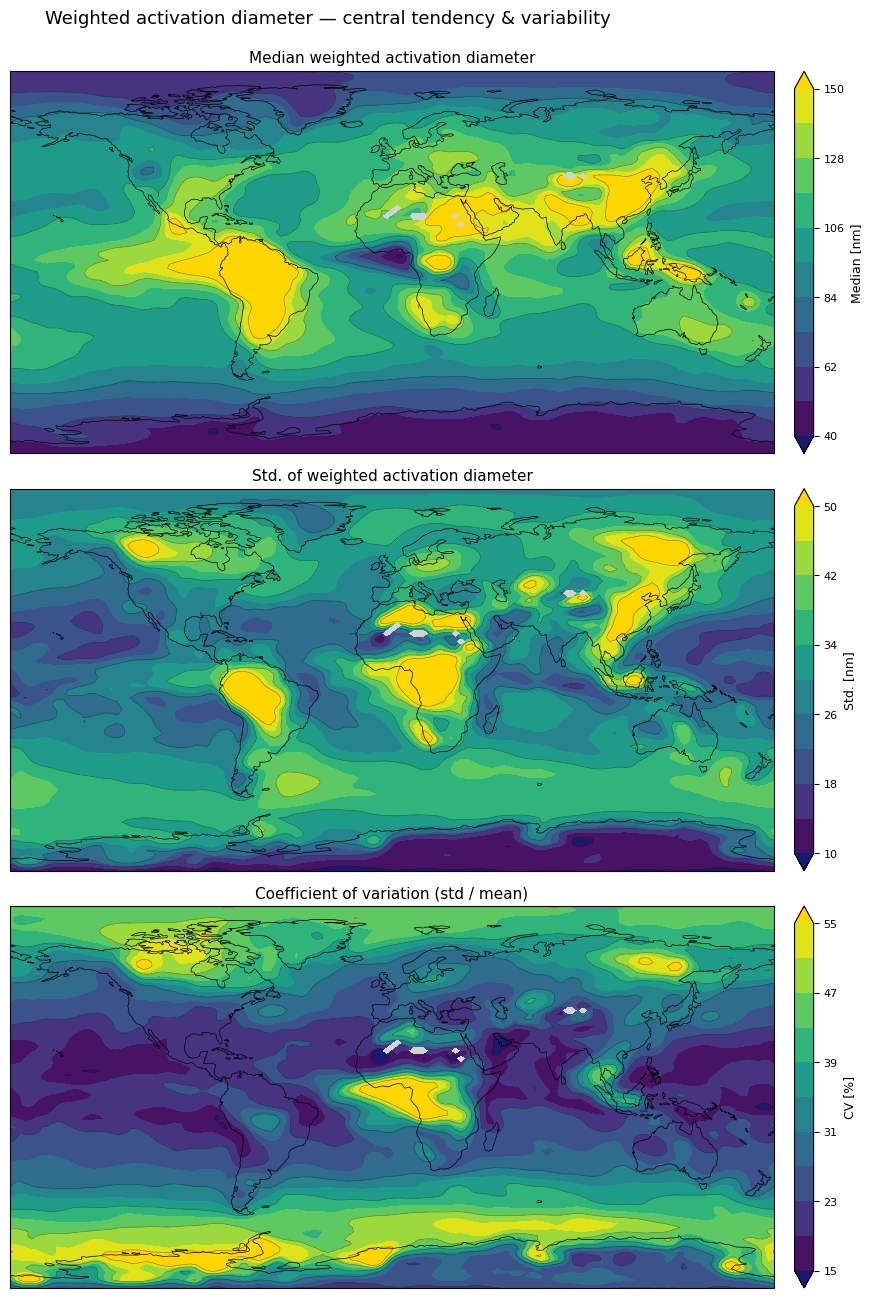

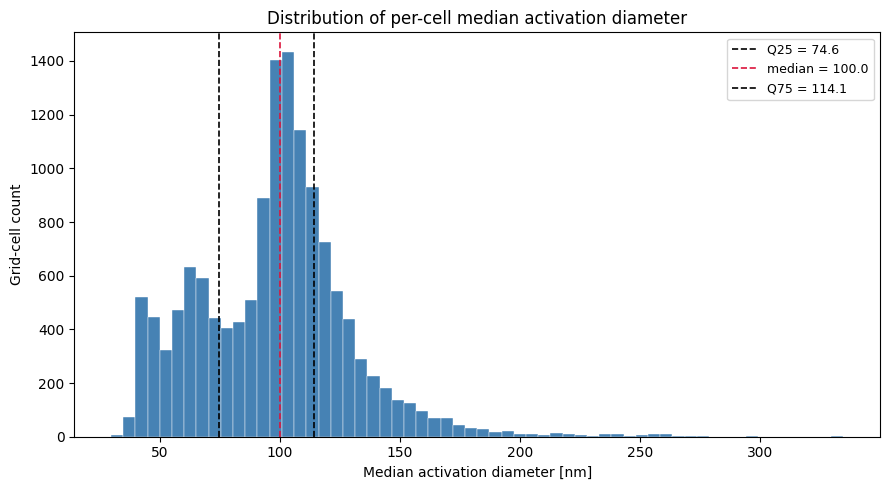

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from scipy.ndimage import gaussian_filter

# ------------------------------------------------------------------
# 0 · Clean field + moments (median, std, mean -> CV) over time & lev
#     Floor at 5 nm removes the weighting artefacts diagnosed earlier.
# ------------------------------------------------------------------
da = ds_actD['Dact_weighted'].where(ds_actD['Dact_weighted'] >= 5)

ActD_med  = da.median(['time', 'lev']).compute().values.astype('float64')
ActD_std  = da.std(['time', 'lev']).compute().values.astype('float64')
ActD_mean = da.mean(['time', 'lev']).compute().values.astype('float64')

with np.errstate(divide='ignore', invalid='ignore'):
    ActD_cv = 100.0 * ActD_std / ActD_mean       # coefficient of variation [%]

# ------------------------------------------------------------------
# 1 · Helper: smooth (NaN-safe, periodic in lon) + close lon loop
# ------------------------------------------------------------------
def prep(field, sigma=1.0):
    mask = np.isfinite(field)
    sm = gaussian_filter(np.where(mask, field, np.nanmedian(field)),
                         sigma=sigma, mode=['nearest', 'wrap'])
    sm[~mask] = np.nan
    sm_c, lon_c = add_cyclic_point(sm, coord=lon)
    return sm_c, lon_c

# ------------------------------------------------------------------
# 2 · Helper: draw one map panel
# ------------------------------------------------------------------
def draw_panel(ax, field, title, cbar_label, unit_round=10):
    sm_c, lon_c = prep(field)
    vmin = np.floor(np.nanquantile(field, 0.05) / unit_round) * unit_round
    vmax = np.ceil (np.nanquantile(field, 0.95) / unit_round) * unit_round
    levels = np.linspace(vmin, vmax, 11)

    cmap = plt.get_cmap('viridis').copy()
    cmap.set_under('midnightblue'); cmap.set_over('gold')

    cf = ax.contourf(lon_c, lat, sm_c, levels=levels, cmap=cmap,
                     transform=ccrs.PlateCarree(), extend='both', zorder=1)
    ax.contour(lon_c, lat, sm_c, levels=levels[::2], colors='k',
               linewidths=0.4, alpha=0.5,
               transform=ccrs.PlateCarree(), zorder=2)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=11)

    cb = fig.colorbar(cf, ax=ax, orientation='vertical', pad=0.02,
                      fraction=0.025, extend='both')
    cb.set_label(cbar_label, fontsize=9)
    cb.ax.tick_params(labelsize=8)

# ------------------------------------------------------------------
# 3 · Three stacked map panels
# ------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(11, 13),
                         subplot_kw={'projection': ccrs.PlateCarree()})

draw_panel(axes[0], ActD_med, 'Median weighted activation diameter',
           'Median [nm]', unit_round=10)
draw_panel(axes[1], ActD_std, 'Std. of weighted activation diameter',
           'Std. [nm]', unit_round=5)
draw_panel(axes[2], ActD_cv,  'Coefficient of variation (std / mean)',
           'CV [%]', unit_round=5)

fig.suptitle('Weighted activation diameter — central tendency & variability',
             fontsize=13, y=0.995)
fig.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4 · Histogram of the per-cell medians
# ------------------------------------------------------------------
med_vals = ActD_med.ravel()
med_vals = med_vals[np.isfinite(med_vals)]

fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.hist(med_vals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)

q25, q50, q75 = np.percentile(med_vals, [25, 50, 75])
for q, c, lab in [(q25, 'k', f'Q25 = {q25:.1f}'),
                  (q50, 'crimson', f'median = {q50:.1f}'),
                  (q75, 'k', f'Q75 = {q75:.1f}')]:
    ax2.axvline(q, color=c, ls='--', lw=1.2, label=lab)

ax2.set_xlabel('Median activation diameter [nm]')
ax2.set_ylabel('Grid-cell count')
ax2.set_title('Distribution of per-cell median activation diameter')
ax2.legend(fontsize=9)
fig2.tight_layout()
plt.show()